In [39]:
import librosa # audio loading and feature extraction
import numpy as np# numerical arrays
import pandas as pd # dataframes
import matplotlib.pyplot as plt# plots
import seaborn as sns
import os

In [40]:
DATASET_PATH = r"C:\01_BME\05_Intro to ML\00_MusicGenre\Data\genres_original"
N_MFCC = 20


In [41]:
def mfcc(file, n_mfcc=N_MFCC):
    """Extract MFCC features from an audio file."""

    try:
        audio, sample_rate = librosa.load(file)
    except Exception as e:
        print(f"Skipping {file} due to load error: {e}")
        return None

    mfcc_matrix = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfcc_matrix.T, axis=0)
    return mfcc_mean


In [42]:
def load_data(dataset_path=DATASET_PATH, n_mfcc=N_MFCC):
    """
    Load the dataset and extract features and labels.

    It goes through each genre folder, and for each audio file,
    it extracts the MFCC features, stores them in a list,
    and also stores the corresponding genre label in another list.
    """

    features = []
    labels = []

    for genre in os.listdir(dataset_path):
        genre_path = os.path.join(dataset_path, genre)

        if os.path.isdir(genre_path):
            for file in os.listdir(genre_path):
                file_path = os.path.join(genre_path, file)

                if file_path.endswith('.wav'):
                    mfcc_features = mfcc(file_path, n_mfcc=n_mfcc)

                    """ 
                    There was a loading error with at least one audio file in the dataset, 
                    to detect which file fails and continue processing, we catch exceptions
                    """
                    if mfcc_features is None:
                        continue

                    features.append(mfcc_features)
                    labels.append(genre)

    return np.array(features), np.array(labels)

In [43]:
# Load the dataset and print some basic information about it to check if its working well

X, y = load_data()

print("Feature matrix shape:", X.shape)
print("Label array shape:", y.shape)
print("Genres found:", np.unique(y))

C:\Users\User\AppData\Local\Temp\ipykernel_17072\3447106086.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sample_rate = librosa.load(file)
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Skipping C:\01_BME\05_Intro to ML\00_MusicGenre\Data\genres_original\jazz\jazz.00054.wav due to load error: 
Feature matrix shape: (999, 20)
Label array shape: (999,)
Genres found: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


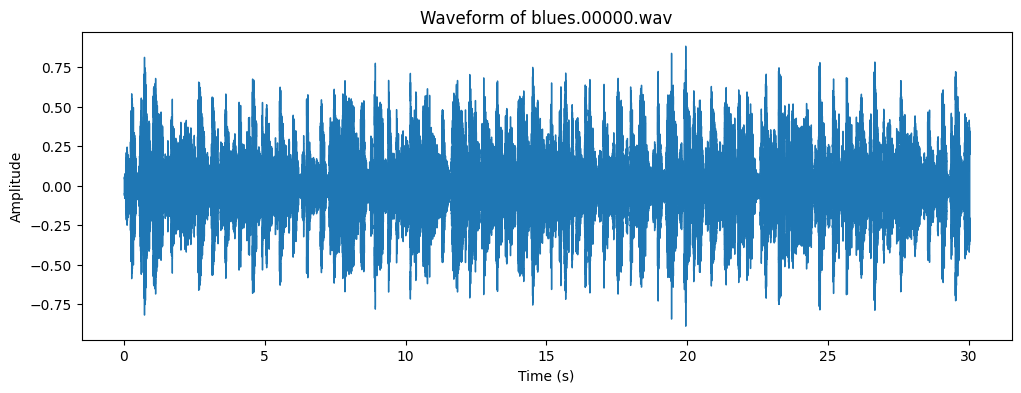

In [44]:
# Plotting the first audio file's waveform and MFCC heatmap for visualization

sample_file = os.path.join(DATASET_PATH, "blues", "blues.00000.wav")

audio, sample_rate = librosa.load(sample_file)

plt.figure(figsize=(12, 4))
librosa.display.waveshow(audio, sr=sample_rate)
plt.title("Waveform of blues.00000.wav")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

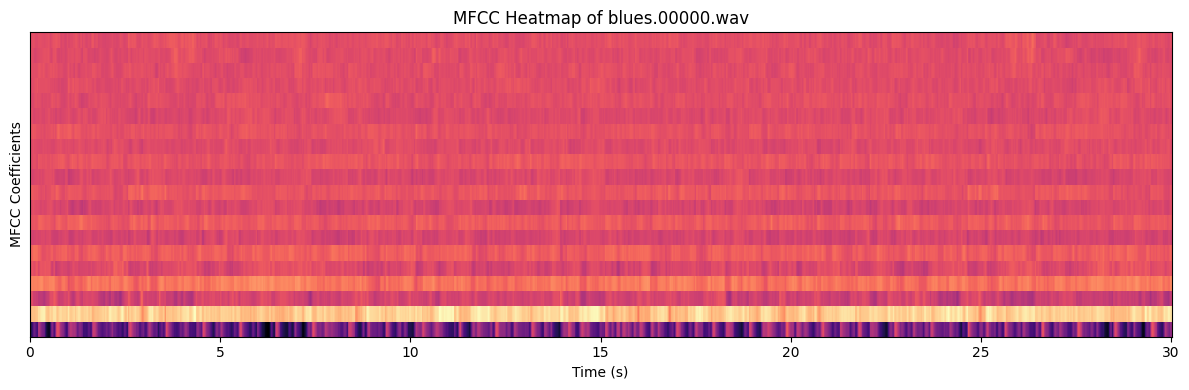

In [45]:
# Extract MFCC features for the sample file

mfcc_matrix = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=N_MFCC)

plt.figure(figsize=(12, 4))
librosa.display.specshow(mfcc_matrix, x_axis='time', sr=sample_rate, cmap='magma')
plt.title("MFCC Heatmap of blues.00000.wav")
plt.xlabel("Time (s)")
plt.ylabel("MFCC Coefficients")
plt.tight_layout()
plt.show()